# Analyse Exploratoire des Données (EDA)

Cette étude a pour objectif d'analyser en profondeur les données relatives aux offres d'emploi (ou concours) de notre dataset. Nous examinerons plusieurs dimensions, telles que :
- La répartition géographique des offres (Région Parisienne vs Province) et son impact sur l'exigence en anglais.
- La relation entre la catégorie de métier et le recours au télétravail.
- Les types de contrats proposés selon les différentes catégories de métiers.
- Les compétences techniques exigées et leurs corrélations.

---

**Rappel :**

A : Sciences du vivant, de la terre et de l'environnement

B : Chimie et sciences des matériaux

C : Sciences de l'ingénieur et instrumentation scientifique

D : Sciences humaines et sociales (SHS)

E : Informatique, statistique et calcul scientifique

F : Culture, Communication, Production et diffusion des savoirs

J : Gestion et Pilotage

## Importation des librairies nécessaires

In [ ]:
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import Nominatim
from scipy.stats import chi2_contingency
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

## 1. Préparation et Nettoyage des données

Chargement du dataset et nettoyage de la variable contenant les noms des villes.

Nombre de postes par ville :
------------------------------
city_clean
paris                     23
marseille                  9
toulouse                   7
villeurbanne               7
orsay                      6
st martin heres            5
gif sur yvette             5
lyon                       5
grenoble                   4
palaiseau                  3
strasbourg                 3
nice                       3
nantes                     3
caen                       2
montpellier                2
pessac                     2
illkirch graffenstaden     2
plouzane                   2
mont st aignan             2
talence                    2
vandoeuvre les nancy       2
aix en provence            2
aubervilliers              1
mulhouse                   1
orleans                    1
prague                     1
guyancourt                 1
villefranche sur mer       1
compiegne                  1
evry courcouronnes         1
avignon                    1
gradignan                  1
c

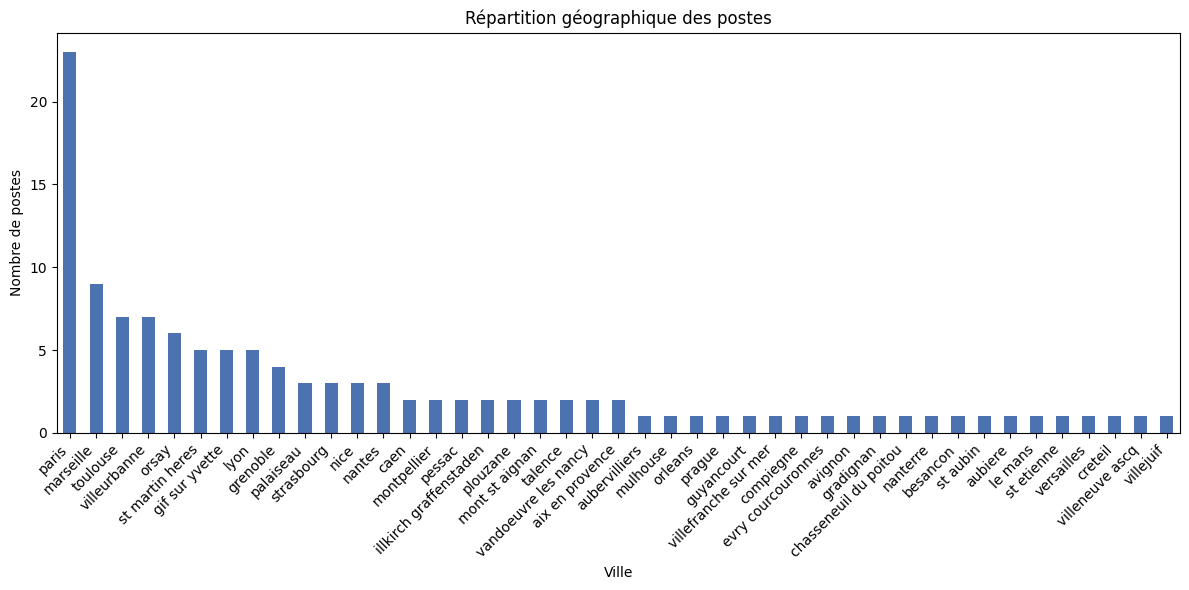

In [ ]:
df = pd.read_csv('concours_dataset_complete_postparsing.csv')


# Si la case contient "laboratoire de chimie, toulouse", on ne garde que "toulouse"
# On gère aussi les valeurs vides (nan) pour éviter les erreurs
df['city_clean'] = df['city'].astype(str).apply(lambda x: x.split(',')[-1].strip() if pd.notna(x) else x)

# On enlève les lignes vides du graphique pour plus de clarté
city_counts = df['city_clean'].replace('nan', pd.NA).dropna().value_counts()

print("Nombre de postes par ville :")
print("-" * 30)
print(city_counts)

plt.figure(figsize=(12, 6)) 
city_counts.plot(kind='bar', color='#4C72B0')

plt.title('Répartition géographique des postes')
plt.xlabel('Ville')
plt.ylabel('Nombre de postes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:

df = pd.read_csv('concours_dataset_complete_postparsing.csv')

df['city_clean'] = df['city'].astype(str).apply(lambda x: x.split(',')[-1].strip())

city_counts = df['city_clean'].value_counts().reset_index()
city_counts.columns = ['city', 'count']

geolocator = Nominatim(user_agent="concours_map_explorer")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

coordinates = {}
for city in city_counts['city']:
    # On ignore les valeurs vides
    if city != "nan" and city != "none" and city != "":
        # On ajoute "France" à la recherche pour aider le GPS
        query = f"{city}, France" if city != "prague" else city
        location = geocode(query)

        if location:
            coordinates[city] = (location.latitude, location.longitude)
        else:
            print(f"Impossible de trouver les coordonnées pour : {city}")

# 4. CRÉATION DE LA CARTE INTERACTIVE AVEC FOLIUM
print("Génération de la carte...")

# On centre la carte sur le milieu de la France
m = folium.Map(location=[46.603354, 1.888334], zoom_start=6, tiles="CartoDB positron")

# On boucle sur nos villes pour ajouter les bulles
for index, row in city_counts.iterrows():
    city = row['city']
    count = row['count']

    if city in coordinates:
        # La taille de la bulle (radius) sera proportionnelle au nombre de postes
        folium.CircleMarker(
            location=coordinates[city],
            radius=count * 1.5 + 3,  # Formule mathématique pour que même les villes avec 1 poste soient visibles
            popup=f"<b>{city.title()}</b><br>{count} poste(s)",
            tooltip=city.title(),
            color="#3186cc",
            fill=True,
            fill_color="#3186cc",
            fill_opacity=0.7
        ).add_to(m)

# 5. Affichage direct dans Colab
m


Génération de la carte...


#### Link carte intéractive

https://antoinej211.github.io/carte-concours-cnrs/

### Analyse de la répartition géographique (Région Parisienne vs Province)

In [ ]:

villes_idf = [
    'paris', 'orsay', 'gif sur yvette', 'palaiseau', 'aubervilliers',
    'guyancourt', 'evry courcouronnes', 'nanterre', 'versailles',
    'creteil', 'villejuif', 'st aubin'
]

df['Region'] = np.where(

    df['city_clean'].isin(villes_idf),
    'Région Parisienne',
    'Province'
)

# Cas de la région hors France
df['Region'] = np.where(df['city_clean'] == 'prague', 'Étranger', df['Region'])

print(df[['city_clean', 'Region']].head(15))

                city_clean             Region
0            aubervilliers  Région Parisienne
1          st martin heres           Province
2                    paris  Région Parisienne
3                   pessac           Province
4                    paris  Région Parisienne
5                    paris  Région Parisienne
6                 plouzane           Province
7   illkirch graffenstaden           Province
8                    orsay  Région Parisienne
9                    paris  Région Parisienne
10                toulouse           Province
11          mont st aignan           Province
12                mulhouse           Province
13              strasbourg           Province
14                   paris  Région Parisienne


In [ ]:
repartition_regions = df['Region'].value_counts()

print(repartition_regions)

Region
Province             76
Région Parisienne    45
Étranger              1
Name: count, dtype: int64


### Test statistique du Chi-2 : Lien entre la région et l'exigence en anglais

In [ ]:
# Test chi2 (1)

tableau_contingence = pd.crosstab(df['Region'], df['english_proficiency'])
print(tableau_contingence)

english_proficiency  B1  B2  C1
Region                         
Province             18  37   4
Région Parisienne     7  21   4
Étranger              0   0   1


In [ ]:
alpha = 0.05

# Exécution du test statistique
chi2, p_value, dof, expected = chi2_contingency(tableau_contingence)

print(f"Statistique du Chi-2 : {chi2:.2f}")
print(f"P-value : {p_value:.5f}")
print(f"Degrés de liberté : {dof}")

print("-" * 50)

if p_value < alpha:
    print("CONCLUSION : On REJETTE l'hypothèse d'indépendance (p < 0.05).")

else:
    print("CONCLUSION : On ACCEPTE l'hypothèse d'indépendance (p > 0.05).")


Statistique du Chi-2 : 10.61
P-value : 0.03125
Degrés de liberté : 4
--------------------------------------------------
CONCLUSION : On REJETTE l'hypothèse d'indépendance (p < 0.05).


### Visualisation : Répartition des niveaux d'anglais selon la région

In [ ]:
tab_pourcentage = pd.crosstab(df['Region'], df['english_proficiency'], normalize='index') * 100

print("Répartition du niveau d'anglais (en %) :")
print(tab_pourcentage.round(1))

Répartition du niveau d'anglais (en %) :
english_proficiency    B1    B2     C1
Region                                
Province             30.5  62.7    6.8
Région Parisienne    21.9  65.6   12.5
Étranger              0.0   0.0  100.0


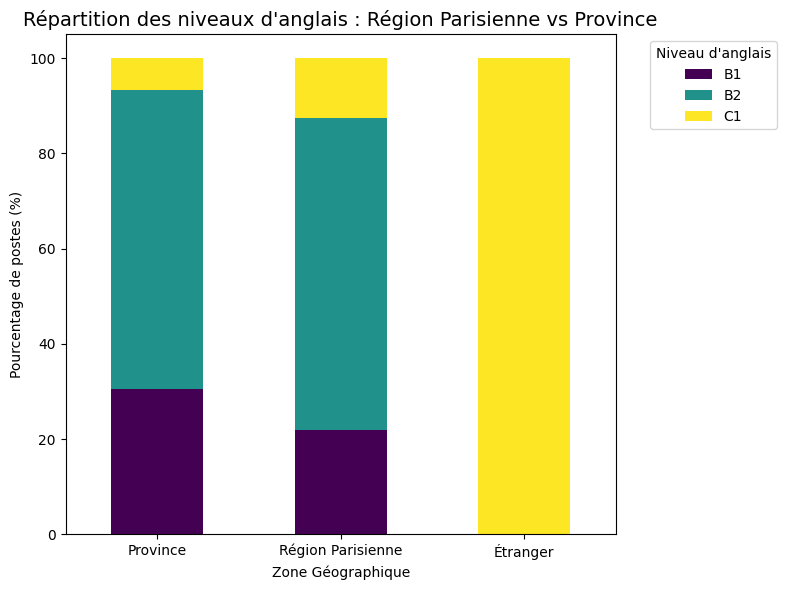

In [ ]:
tab_pourcentage.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')

plt.title("Répartition des niveaux d'anglais : Région Parisienne vs Province", fontsize=14)
plt.ylabel("Pourcentage de postes (%)")
plt.xlabel("Zone Géographique")
plt.xticks(rotation=0)

plt.legend(title="Niveau d'anglais", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Test statistique du Chi-2 : Lien entre la catégorie de métier et le télétravail

In [ ]:
# Test chi2 (2)

tableau_contingence2 = pd.crosstab(df['job_category'], df['remote_work'])
print(tableau_contingence2)

remote_work    0   1
job_category        
A              9   2
B             20   2
C             26   4
D             11   5
E             22  15
F              2   2
J              2   0


In [ ]:

chi2, p_value, dof, expected = chi2_contingency(tableau_contingence2)

print(f"Statistique du Chi-2 : {chi2:.2f}")
print(f"P-value : {p_value:.5f}")
print(f"Degrés de liberté : {dof}")

print("-" * 50)

if p_value < alpha:
    print("CONCLUSION : On REJETTE l'hypothèse d'indépendance (p < 0.05).")

else:
    print("CONCLUSION : On ACCEPTE l'hypothèse d'indépendance (p > 0.05).")


Statistique du Chi-2 : 12.65
P-value : 0.04898
Degrés de liberté : 6
--------------------------------------------------
CONCLUSION : On REJETTE l'hypothèse d'indépendance (p < 0.05).


### Visualisation : Répartition du télétravail selon le métier

In [ ]:
profils_metiers = pd.crosstab(df['job_category'], df['remote_work'], normalize='index') * 100
print("\nProfils de télétravail par métier :")
print(profils_metiers.round(1))

# Calcul du V de Cramer
n = tableau_contingence2.sum().sum()
min_dimensions = min(tableau_contingence2.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dimensions))
print(f"\nForce de la dépendance (V de Cramér) : {cramer_v:.3f}")


Profils de télétravail par métier :
remote_work       0     1
job_category             
A              81.8  18.2
B              90.9   9.1
C              86.7  13.3
D              68.8  31.2
E              59.5  40.5
F              50.0  50.0
J             100.0   0.0

Force de la dépendance (V de Cramér) : 0.322


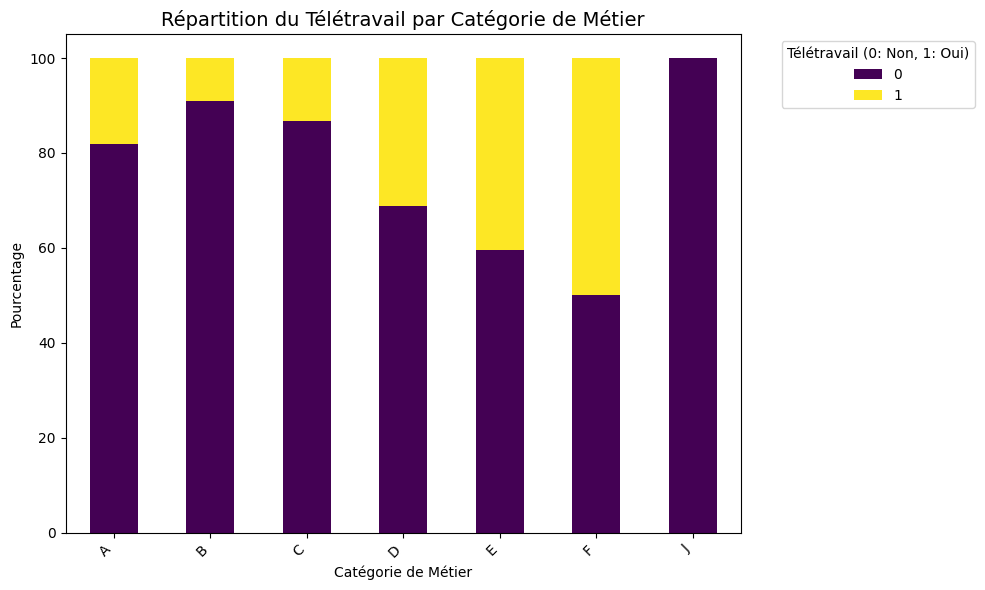

In [ ]:
profils_metiers.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Répartition du Télétravail par Catégorie de Métier", fontsize=14)
plt.ylabel("Pourcentage")
plt.xlabel("Catégorie de Métier")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Télétravail (0: Non, 1: Oui)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Test statistique du Chi-2 : Lien entre le type de contrat et la catégorie de métier

In [ ]:
# Test chi2 (3)

tableau_contingence3 = pd.crosstab(df['job_type'], df['job_category'])
print(tableau_contingence3)

job_category   A   B   C   D   E  F  J
job_type                              
IE             0  11  13   4  16  0  0
IR            11  11  17  12  21  4  2


In [ ]:

chi2, p_value, dof, expected = chi2_contingency(tableau_contingence3)

print(f"Statistique du Chi-2 : {chi2:.2f}")
print(f"P-value : {p_value:.5f}")
print(f"Degrés de liberté : {dof}")

print("-" * 50)

if p_value < alpha:
    print("CONCLUSION : On REJETTE l'hypothèse d'indépendance (p < 0.05).")

else:
    print("CONCLUSION : On ACCEPTE l'hypothèse d'indépendance (p > 0.05).")


Statistique du Chi-2 : 13.81
P-value : 0.03188
Degrés de liberté : 6
--------------------------------------------------
CONCLUSION : On REJETTE l'hypothèse d'indépendance (p < 0.05).


### Vérification des valeurs manquantes pour les variables catégorielles

In [ ]:
df['job_type'].isna().value_counts()

,count
job_type,
False,122


In [ ]:

df['job_category'].isna().value_counts()

,count
job_category,
False,122


### Visualisation : Types de contrat selon la catégorie de métier

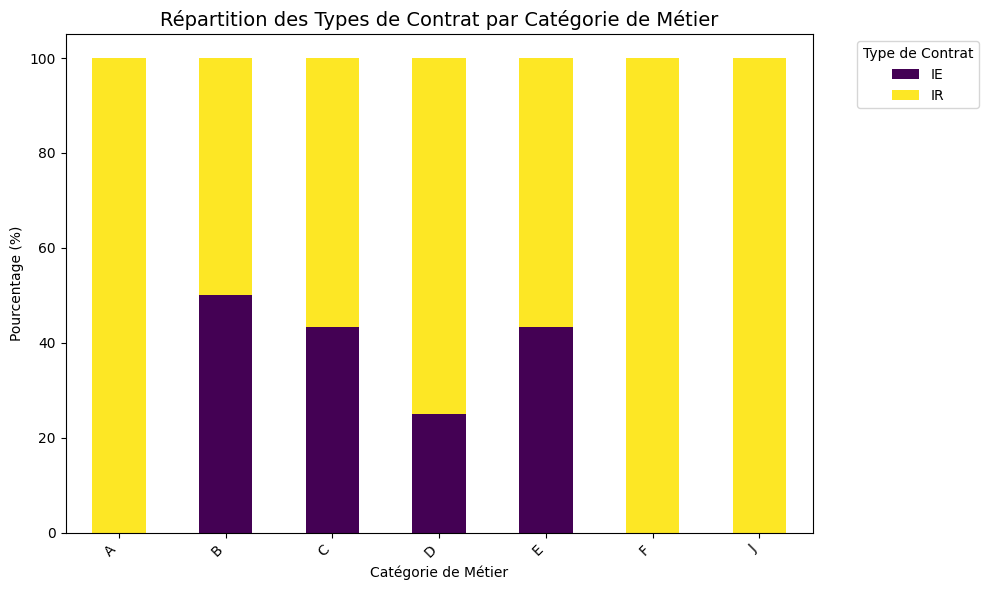

In [ ]:
tab_pourcentage = pd.crosstab(df['job_category'], df['job_type'], normalize='index') * 100

tab_pourcentage.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title("Répartition des Types de Contrat par Catégorie de Métier", fontsize=14)
plt.ylabel("Pourcentage (%)")
plt.xlabel("Catégorie de Métier")

plt.xticks(rotation=45, ha='right')
plt.legend(title="Type de Contrat", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Analyse des compétences demandées (selon la catégorie d'emploi)
Comparaison de la demande en compétences selon la catégorie d'emploi (`job_category`).

In [ ]:

# Liste des compétences
skills = ['has_r', 'has_python', 'has_ml', 'it_skills', 'stat_methods']
for skill in skills:
    df[skill] = pd.to_numeric(df[skill], errors='coerce').fillna(0)


df_cat = df.dropna(subset=['job_category'])

print("Proportion de postes demandant chaque compétence par catégorie d'emploi :")
print("-" * 60)
for skill in skills:

    contingency = pd.crosstab(df_cat['job_category'], df_cat[skill])

    # Afin d'éviter un warning si une compétence n'est pas demandée
    if contingency.shape[1] > 1:

        chi2, p, dof, expected = stats.chi2_contingency(contingency)
    else:
        p = 1.0 # Pas de différence si la compétence n'a qu'une seule valeur

    print(f"Compétence : {skill}")
    # Calcul des pourcentages pour chaque catégorie
    if 1 in contingency.columns:
        for cat in contingency.index:
            total_cat = contingency.loc[cat].sum()
            count = contingency.loc[cat, 1]
            prop = count / total_cat * 100 if total_cat > 0 else 0
            print(f"  Catégorie {cat} : {prop:.1f}% ({count}/{total_cat})")

    print(f"  p-value du test Chi-2 : {p:.4f}")
    if p < 0.05:
        print("  -> Différence statistiquement significative selon la catégorie d'emploi !")
    else:
        print("  -> Pas de différence significative selon la catégorie.")
    print("-" * 60)

Proportion de postes demandant chaque compétence par catégorie d'emploi :
------------------------------------------------------------
Compétence : has_r
  Catégorie A : 63.6% (7/11)
  Catégorie B : 27.3% (6/22)
  Catégorie C : 13.3% (4/30)
  Catégorie D : 43.8% (7/16)
  Catégorie E : 21.6% (8/37)
  Catégorie F : 25.0% (1/4)
  Catégorie J : 0.0% (0/2)
  p-value du test Chi-2 : 0.0309
  -> Différence statistiquement significative selon la catégorie d'emploi !
------------------------------------------------------------
Compétence : has_python
  Catégorie A : 54.5% (6/11)
  Catégorie B : 9.1% (2/22)
  Catégorie C : 50.0% (15/30)
  Catégorie D : 31.2% (5/16)
  Catégorie E : 75.7% (28/37)
  Catégorie F : 25.0% (1/4)
  Catégorie J : 0.0% (0/2)
  p-value du test Chi-2 : 0.0001
  -> Différence statistiquement significative selon la catégorie d'emploi !
------------------------------------------------------------
Compétence : has_ml
  Catégorie A : 100.0% (11/11)
  Catégorie B : 100.0% (22/22)

## 3. Matrice de corrélation des compétences
Analyse des associations entre les différentes compétences demandées.

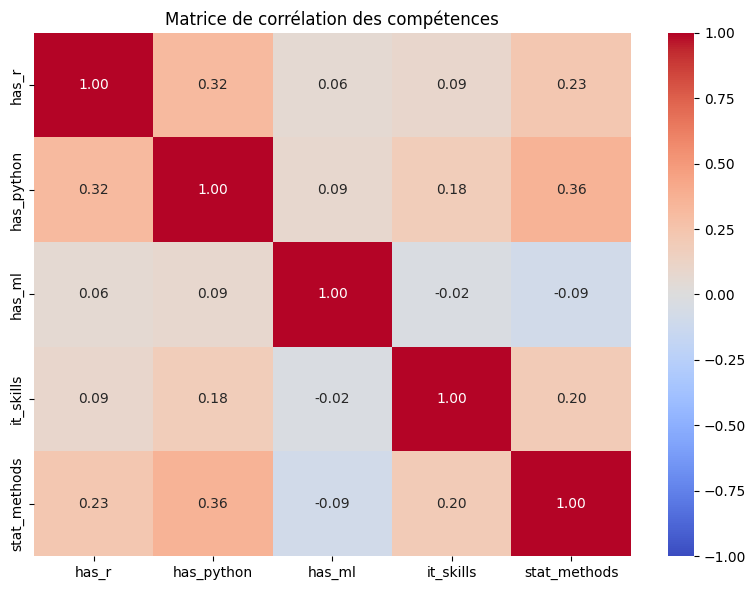

In [ ]:

plt.figure(figsize=(8, 6))
corr_matrix = df[skills].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Matrice de corrélation des compétences')
plt.tight_layout()
plt.show()